In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/._trimaps
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/README
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/test.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/trainval.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/list.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/staffordshire_bull_terrier_165.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/saint_bernard_182.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/Birman_151.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/British_Shorthair_180.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/Birman_15

In [3]:
import os
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def apply_salt_and_pepper(img_tensor):
    p = random.uniform(0.02, 0.15)
    mask = torch.rand(img_tensor.shape[1:]) # [H, W]
    corrupted = img_tensor.clone()
    corrupted[:, mask < p/2] = 1.0 # Salt (White)
    corrupted[:, (mask >= p/2) & (mask < p)] = 0.0 # Pepper (Black)
    return corrupted

def apply_gaussian_blur(img_tensor):
    k = random.choice([3, 5, 7])
    sigma = random.uniform(0.5, 2.5)
    return TF.gaussian_blur(img_tensor, kernel_size=[k, k], sigma=[sigma, sigma])

def apply_occlusion(img_tensor):
    c, h, w = img_tensor.shape
    num_rects = random.randint(1, 3)
    target_area_ratio = random.uniform(0.10, 0.35)
    total_area = h * w
    area_per_rect = (target_area_ratio * total_area) / num_rects
    
    corrupted = img_tensor.clone()
    for _ in range(num_rects):
        aspect_ratio = random.uniform(0.5, 2.0)
        rect_h = max(1, min(h, int((area_per_rect * aspect_ratio) ** 0.5)))
        rect_w = max(1, min(w, int((area_per_rect / aspect_ratio) ** 0.5)))
        
        top = random.randint(0, max(1, h - rect_h))
        left = random.randint(0, max(1, w - rect_w))
        
        corrupted[:, top:top+rect_h, left:left+rect_w] = 0.0 # Black out the region
    return corrupted

def apply_random_corruption(img_tensor, is_training=True, seed=None):
    """
    Applies one of the four corruptions dynamically.
    For validation, we pass a seed to make the corruption deterministic (manifest).
    """
    if not is_training and seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
        
    choice = random.randint(0, 3)
    
    if choice == 0:
        corrupted = img_tensor.clone()
        label = "Clean"
    elif choice == 1:
        corrupted = apply_salt_and_pepper(img_tensor)
        label = "Salt & Pepper"
    elif choice == 2:
        corrupted = apply_gaussian_blur(img_tensor)
        label = "Gaussian Blur"
    else:
        corrupted = apply_occlusion(img_tensor)
        label = "Occlusion"
        
    # Reset seed to random if we fixed it for validation
    if not is_training:
        random.seed()
        torch.seed()
        
    return corrupted, choice, label

In [6]:
class PetCorruptionDataset(Dataset):
    root_dir = "/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet"
    
    def __init__(self, root_dir, is_training=True):
        # Base transform: Resize to 128x128 and convert to Tensor [0, 1]
        self.base_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])
        
        # Load the dataset (Kaggle usually has the images inside an 'images' folder)
        import glob
        from PIL import Image
        
        # Grab all jpgs
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, "images", "*.jpg")))
        if len(self.image_paths) == 0:
             print(f"Warning: No images found in {os.path.join(root_dir, 'images')}")
        
        # The assignment requires an 80/20 train/val split using seed 42.
        dataset_size = len(self.image_paths)
        indices = list(range(dataset_size))
        np.random.seed(42)
        np.random.shuffle(indices)
        split_idx = int(np.floor(0.2 * dataset_size)) # 20% for val
        
        if is_training:
            self.indices = indices[split_idx:]
        else:
            self.indices = indices[:split_idx]
            
        self.is_training = is_training
        
    def __len__(self):
        return len(self.indices)
        
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img_path = self.image_paths[actual_idx]
        
        # Load image and convert to RGB (some might be grayscale or have alpha channel)
        from PIL import Image
        clean_img = Image.open(img_path).convert("RGB")
        clean_tensor = self.base_transform(clean_img)
        
        # For validation, we use the actual dataset index as a seed so it is completely deterministic
        seed = None if self.is_training else actual_idx
        
        corrupted_tensor, corruption_idx, corruption_label = apply_random_corruption(clean_tensor, self.is_training, seed)
        
        return corrupted_tensor, clean_tensor, corruption_label

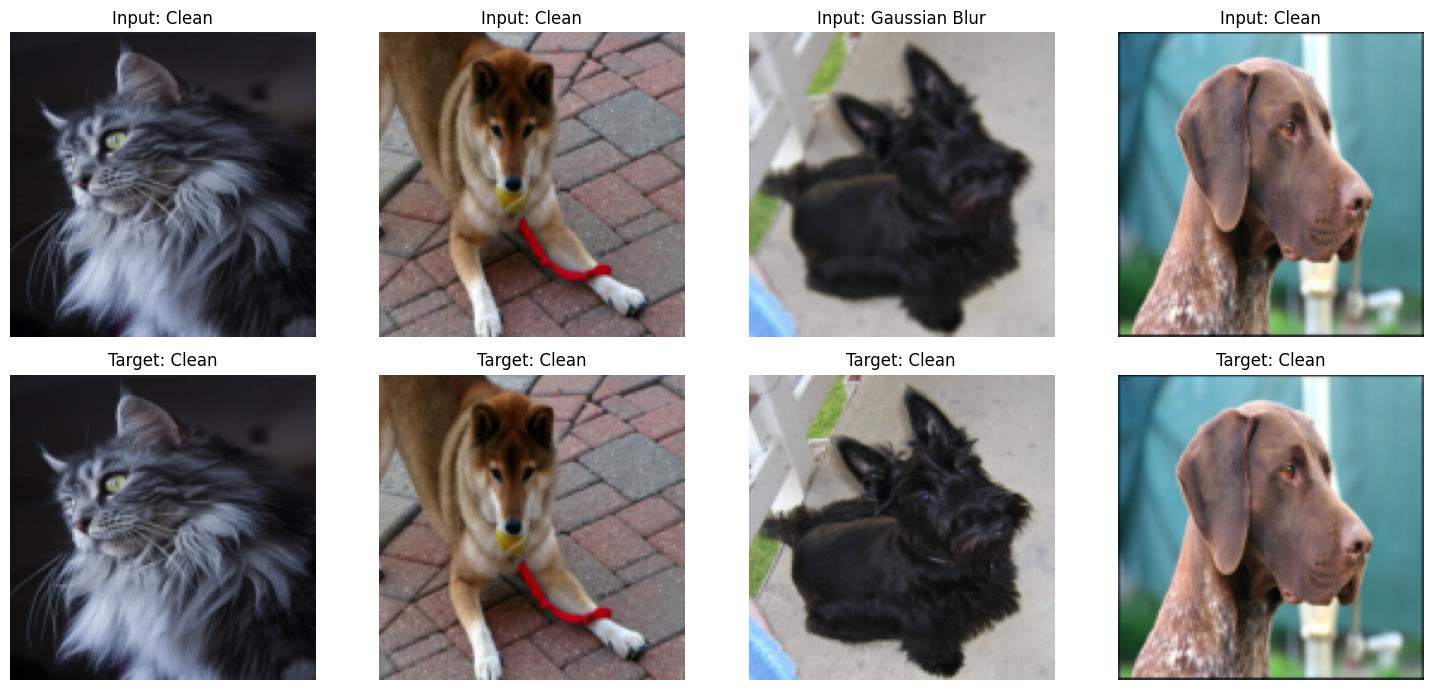

In [7]:
# Change this path to match Kaggle's input path (e.g., "/kaggle/input/oxford-iiit-pet")
KAGGLE_DATA_DIR = "/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/images" 

train_dataset = PetCorruptionDataset(root_dir=KAGGLE_DATA_DIR, is_training=True)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Fetch a batch
corrupted_imgs, clean_imgs, labels = next(iter(train_loader))

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i in range(4):
    # Plot Corrupted (Inputs)
    ax = axes[0, i]
    ax.imshow(corrupted_imgs[i].permute(1, 2, 0).numpy())
    ax.set_title(f"Input: {labels[i]}")
    ax.axis("off")
    
    # Plot Clean (Targets)
    ax = axes[1, i]
    ax.imshow(clean_imgs[i].permute(1, 2, 0).numpy())
    ax.set_title("Target: Clean")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import torch.nn as nn

class UniversalAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim=256, base_channels=32, dropout_rate=0.0):
        super(UniversalAutoencoder, self).__init__()
        self.base_channels = base_channels
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.Conv2d(base_channels, base_channels*2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.Conv2d(base_channels*4, base_channels*8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.Flatten()
        )
        
        flattened_size = 8 * 8 * (base_channels * 8)
        self.fc_encode = nn.Linear(flattened_size, bottleneck_dim)
        self.fc_decode = nn.Linear(bottleneck_dim, flattened_size)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels*8, base_channels*4, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            
            nn.ConvTranspose2d(base_channels, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.encoder(x)
        latent = self.fc_encode(x)
        x = self.fc_decode(latent)
        x = x.view(-1, self.base_channels * 8, 8, 8) 
        reconstruction = self.decoder(x)
        return reconstruction

In [9]:
# First, run a quick pip install just in case torchmetrics isn't active on your kernel
!pip install -q torchmetrics

from torchmetrics.image import StructuralSimilarityIndexMeasure

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.8, device='cpu'):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.l1_loss = nn.L1Loss()
        
        # SSIM expects data in [0, 1] range, so we set data_range=1.0
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
        
    def forward(self, pred, target):
        # Calculate L1
        l1 = self.l1_loss(pred, target)
        
        # Calculate SSIM
        ssim_val = self.ssim(pred, target)
        
        # SSIM is 1 for identical images, so the loss is (1 - SSIM)
        ssim_loss = 1.0 - ssim_val
        
        # Combine them as specified in the assignment PDF
        total_loss = (self.alpha * l1) + ((1.0 - self.alpha) * ssim_loss)
        
        return total_loss, l1, ssim_loss

# Instantiate the loss function
criterion = CombinedLoss(alpha=0.8, device=device)

In [11]:
import time
import torch.optim as optim

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    # Dictionary to keep track of history for plotting later
    history = {'train_loss': [], 'val_loss': [], 'train_ssim': [], 'val_ssim': []}
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        running_ssim = 0.0
        
        for corrupted, clean, _ in train_loader:
            corrupted, clean = corrupted.to(device), clean.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(corrupted)
            
            # Calculate loss
            loss, l1_loss, ssim_loss = criterion(outputs, clean)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * corrupted.size(0)
            running_ssim += (1.0 - ssim_loss.item()) * corrupted.size(0) # Store actual SSIM value
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_ssim = running_ssim / len(train_loader.dataset)
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        val_ssim = 0.0
        
        with torch.no_grad():
            for corrupted, clean, _ in val_loader:
                corrupted, clean = corrupted.to(device), clean.to(device)
                outputs = model(corrupted)
                
                loss, l1_loss, ssim_loss = criterion(outputs, clean)
                
                val_loss += loss.item() * corrupted.size(0)
                val_ssim += (1.0 - ssim_loss.item()) * corrupted.size(0)
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_ssim = val_ssim / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_ssim'].append(epoch_train_ssim)
        history['val_ssim'].append(epoch_val_ssim)
        
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} [{time_elapsed:.0f}s] "
              f"Train Loss: {epoch_train_loss:.4f} (SSIM: {epoch_train_ssim:.4f}) | "
              f"Val Loss: {epoch_val_loss:.4f} (SSIM: {epoch_val_ssim:.4f})")
              
    return history

In [14]:
# 1. Setup the Validation Dataset
# (Make sure KAGGLE_DATA_DIR matches what you used in Step 1)
KAGGLE_DATA_DIR = "/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/images" 
val_dataset = PetCorruptionDataset(root_dir=KAGGLE_DATA_DIR, is_training=False)

# 2. Setup DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 3. Initialize model, loss, optimizer
model = UniversalAutoencoder(bottleneck_dim=256, base_channels=32).to(device)
criterion = CombinedLoss(alpha=0.8, device=device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4. Train!
print("Starting initial training test...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Starting initial training test...
Epoch 1/5 [25s] Train Loss: 0.2555 (SSIM: 0.3565) | Val Loss: 0.2144 (SSIM: 0.4037)
Epoch 2/5 [22s] Train Loss: 0.2070 (SSIM: 0.4120) | Val Loss: 0.1971 (SSIM: 0.4318)
Epoch 3/5 [22s] Train Loss: 0.1951 (SSIM: 0.4340) | Val Loss: 0.1916 (SSIM: 0.4436)
Epoch 4/5 [22s] Train Loss: 0.1887 (SSIM: 0.4482) | Val Loss: 0.1839 (SSIM: 0.4597)
Epoch 5/5 [22s] Train Loss: 0.1834 (SSIM: 0.4610) | Val Loss: 0.1799 (SSIM: 0.4701)


In [16]:
!pip install -q optuna
import optuna

def objective(trial):
    # 1. Ask Optuna to suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    bottleneck_dim = trial.suggest_categorical("bottleneck_dim", [128, 256, 512])
    base_channels = trial.suggest_categorical("base_channels", [16, 32])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    alpha = trial.suggest_float("alpha", 0.1, 0.9)
    
    # 2. Setup DataLoaders with the suggested batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # 3. Initialize Model, Loss, Optimizer with suggested parameters
    model = UniversalAutoencoder(
        bottleneck_dim=bottleneck_dim, 
        base_channels=base_channels,
        dropout_rate=dropout_rate
    ).to(device)
    
    criterion = CombinedLoss(alpha=alpha, device=device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 4. Train for a short epoch budget (e.g., 3 epochs) to test this configuration
    history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=3)
    
    # The objective we want to minimize is the final validation loss
    final_val_loss = history['val_loss'][-1]
    return final_val_loss

print("Starting Optuna Hyperparameter Search...")
# Create a study object and optimize it!
# (We use n_trials=5 here just so you don't wait hours. For your final run, change to 20 or 30)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=5) 

print("\n--- OPTUNA SEARCH COMPLETE ---")
print("Best trial:")
best_trial = study.best_trial
print(f"  Best Validation Loss: {best_trial.value}")
print("  Best Hyperparameters: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-09-25 15:00:01,416] A new study created in memory with name: no-name-2d0a065a-6b46-4378-ae43-93a5812fbcd0


Starting Optuna Hyperparameter Search...
Epoch 1/3 [25s] Train Loss: 0.5310 (SSIM: 0.3186) | Val Loss: 0.5210 (SSIM: 0.3313)
Epoch 2/3 [22s] Train Loss: 0.5265 (SSIM: 0.3231) | Val Loss: 0.5209 (SSIM: 0.3314)


[I 2026-09-25 15:01:11,555] Trial 0 finished with value: 0.5209797876452238 and parameters: {'lr': 0.007909873055846815, 'batch_size': 64, 'bottleneck_dim': 256, 'base_channels': 32, 'dropout_rate': 0.11962326861920514, 'alpha': 0.3284472473861948}. Best is trial 0 with value: 0.5209797876452238.


Epoch 3/3 [23s] Train Loss: 0.5265 (SSIM: 0.3231) | Val Loss: 0.5210 (SSIM: 0.3313)
Epoch 1/3 [24s] Train Loss: 0.3864 (SSIM: 0.3211) | Val Loss: 0.3493 (SSIM: 0.3495)
Epoch 2/3 [24s] Train Loss: 0.3446 (SSIM: 0.3483) | Val Loss: 0.3252 (SSIM: 0.3844)


[I 2026-09-25 15:02:23,178] Trial 1 finished with value: 0.32639425847785236 and parameters: {'lr': 0.00023319524197286764, 'batch_size': 16, 'bottleneck_dim': 128, 'base_channels': 16, 'dropout_rate': 0.299656667037124, 'alpha': 0.6354028491484643}. Best is trial 1 with value: 0.32639425847785236.


...

Epoch 3/3 [22s] Train Loss: 0.6208 (SSIM: 0.3217) | Val Loss: 0.6130 (SSIM: 0.3304)
Epoch 1/3 [22s] Train Loss: 0.4138 (SSIM: 0.3232) | Val Loss: 0.3860 (SSIM: 0.3513)
Epoch 2/3 [22s] Train Loss: 0.3912 (SSIM: 0.3406) | Val Loss: 0.3679 (SSIM: 0.3689)


[I 2026-09-25 15:04:38,130] Trial 3 finished with value: 0.3633306434980426 and parameters: {'lr': 0.0029794056116019887, 'batch_size': 64, 'bottleneck_dim': 512, 'base_channels': 32, 'dropout_rate': 0.2539163689843724, 'alpha': 0.5683436157307067}. Best is trial 1 with value: 0.32639425847785236.


Epoch 3/3 [23s] Train Loss: 0.3804 (SSIM: 0.3504) | Val Loss: 0.3633 (SSIM: 0.3730)
Epoch 1/3 [22s] Train Loss: 0.2877 (SSIM: 0.3257) | Val Loss: 0.2441 (SSIM: 0.3677)
Epoch 2/3 [22s] Train Loss: 0.2288 (SSIM: 0.3731) | Val Loss: 0.2133 (SSIM: 0.4022)


[I 2026-09-25 15:05:44,404] Trial 4 finished with value: 0.20613758493824805 and parameters: {'lr': 0.0014581905063314482, 'batch_size': 64, 'bottleneck_dim': 128, 'base_channels': 16, 'dropout_rate': 0.03416438462676974, 'alpha': 0.8009521704058383}. Best is trial 4 with value: 0.20613758493824805.


Epoch 3/3 [22s] Train Loss: 0.2122 (SSIM: 0.4024) | Val Loss: 0.2061 (SSIM: 0.4225)

--- OPTUNA SEARCH COMPLETE ---
Best trial:
  Best Validation Loss: 0.20613758493824805
  Best Hyperparameters: 
    lr: 0.0014581905063314482
    batch_size: 64
    bottleneck_dim: 128
    base_channels: 16
    dropout_rate: 0.03416438462676974
    alpha: 0.8009521704058383


In [17]:
print("Training Final Model with Best Hyperparameters...")
best_params = study.best_trial.params

# 1. Setup DataLoaders with the best batch size
final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, num_workers=2)
final_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=2)

# 2. Initialize the Model with best architecture parameters
final_model = UniversalAutoencoder(
    bottleneck_dim=best_params['bottleneck_dim'], 
    base_channels=best_params['base_channels'],
    dropout_rate=best_params['dropout_rate']
).to(device)

# 3. Initialize Loss and Optimizer
final_criterion = CombinedLoss(alpha=best_params['alpha'], device=device)
final_optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])

# 4. Train the final model! (We'll do 10 epochs, but for a real assignment submission, you might want 30-50!)
final_history = train_model(final_model, final_train_loader, final_val_loader, final_criterion, final_optimizer, num_epochs=10)

# 5. Save the raw PyTorch weights
torch.save(final_model.state_dict(), "universal_autoencoder_best.pth")
print("Final model weights saved to universal_autoencoder_best.pth")

Training Final Model with Best Hyperparameters...
Epoch 1/10 [27s] Train Loss: 0.2982 (SSIM: 0.3249) | Val Loss: 0.2621 (SSIM: 0.3611)
Epoch 2/10 [21s] Train Loss: 0.2413 (SSIM: 0.3630) | Val Loss: 0.2192 (SSIM: 0.3922)
Epoch 3/10 [22s] Train Loss: 0.2212 (SSIM: 0.3901) | Val Loss: 0.2122 (SSIM: 0.4103)
Epoch 4/10 [21s] Train Loss: 0.2117 (SSIM: 0.4049) | Val Loss: 0.2023 (SSIM: 0.4229)
Epoch 5/10 [22s] Train Loss: 0.2054 (SSIM: 0.4164) | Val Loss: 0.2001 (SSIM: 0.4297)
Epoch 6/10 [22s] Train Loss: 0.2011 (SSIM: 0.4249) | Val Loss: 0.1993 (SSIM: 0.4338)
Epoch 7/10 [21s] Train Loss: 0.1984 (SSIM: 0.4303) | Val Loss: 0.1931 (SSIM: 0.4418)
Epoch 8/10 [21s] Train Loss: 0.1955 (SSIM: 0.4365) | Val Loss: 0.1930 (SSIM: 0.4468)
Epoch 9/10 [21s] Train Loss: 0.1923 (SSIM: 0.4429) | Val Loss: 0.1919 (SSIM: 0.4522)
Epoch 10/10 [21s] Train Loss: 0.1900 (SSIM: 0.4485) | Val Loss: 0.1852 (SSIM: 0.4589)
Final model weights saved to universal_autoencoder_best.pth


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.5 MB/s eta 0:00:00


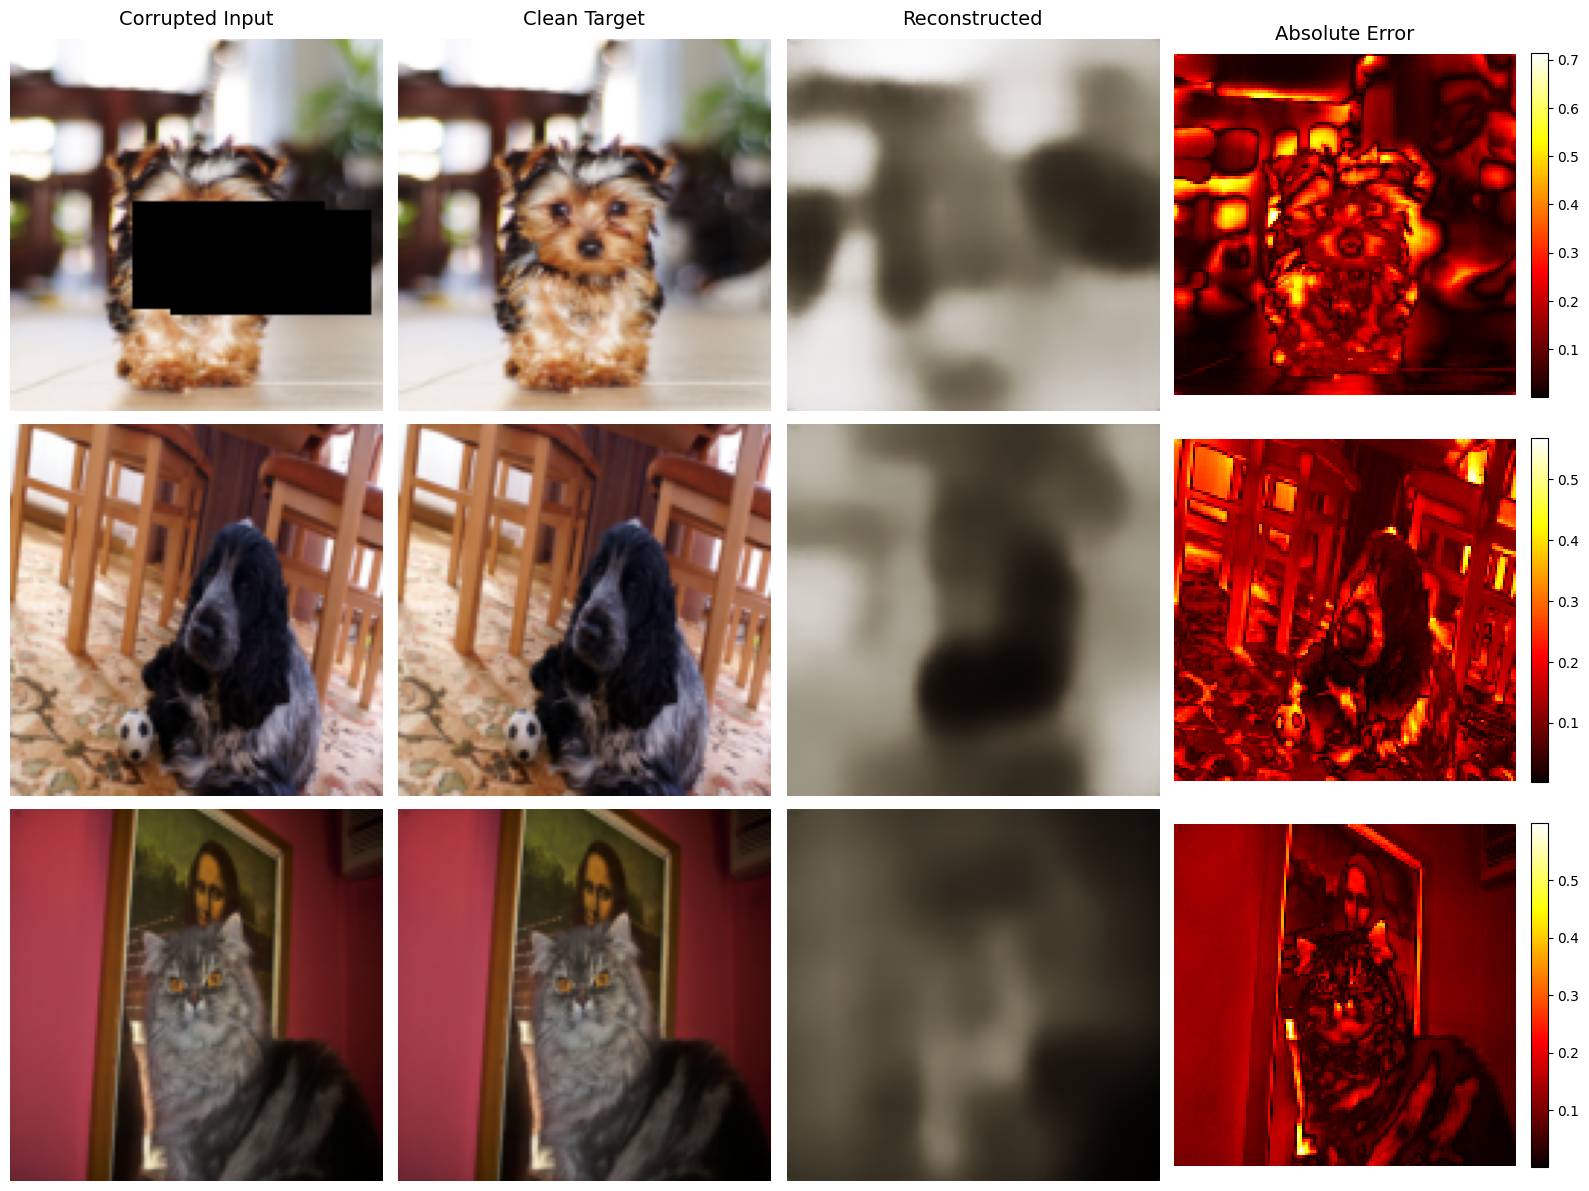

/tmp/ipykernel_58/2167680254.py:57: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0925 15:25:32.332000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0925 15:25:33.167000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

Model successfully exported to universal_autoencoder.onnx!
Task 1 is officially complete. You can download this ONNX file from Kaggle's /working directory to use in your web app.


In [20]:
!pip install -q onnx onnxscript
import onnx
import onnxscript

final_model.eval()


# Grab one batch from validation for visualization
corrupted_imgs, clean_imgs, labels = next(iter(final_val_loader))
corrupted_imgs, clean_imgs = corrupted_imgs.to(device), clean_imgs.to(device)

with torch.no_grad():
    reconstructed = final_model(corrupted_imgs)
    
# Calculate Absolute Error Map: |Input - Reconstructed|
error_maps = torch.abs(clean_imgs - reconstructed)

# Move tensors to CPU for matplotlib
corrupted_imgs = corrupted_imgs.cpu().permute(0, 2, 3, 1).numpy()
clean_imgs = clean_imgs.cpu().permute(0, 2, 3, 1).numpy()
reconstructed = reconstructed.cpu().permute(0, 2, 3, 1).numpy()
error_maps = error_maps.cpu().permute(0, 2, 3, 1).numpy()

# Aggregate the RGB error map into a single grayscale channel for a nice heatmap
error_maps_gray = np.mean(error_maps, axis=-1)

# Plot first 3 examples from the batch
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ['Corrupted Input', 'Clean Target', 'Reconstructed', 'Absolute Error']

# Set column titles
for ax, col in zip(axes[0], col_titles):
    ax.set_title(col, fontsize=14, pad=10)

for i in range(3):
    axes[i, 0].imshow(corrupted_imgs[i])
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(clean_imgs[i])
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(reconstructed[i])
    axes[i, 2].axis('off')
    
    # Error Map Heatmap
    im = axes[i, 3].imshow(error_maps_gray[i], cmap='hot', interpolation='nearest')
    axes[i, 3].axis('off')
    fig.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# --- ONNX EXPORT ---
onnx_file_path = "universal_autoencoder.onnx"
dummy_input = torch.randn(1, 3, 128, 128).to(device)

torch.onnx.export(
    final_model,               
    dummy_input,               
    onnx_file_path,            
    export_params=True,        
    opset_version=11,          
    do_constant_folding=True,  
    input_names = ['input'],   
    output_names = ['output'], 
    dynamic_axes={'input' : {0 : 'batch_size'}, 'output' : {0 : 'batch_size'}}
)

print(f"\nModel successfully exported to {onnx_file_path}!")
print("Task 1 is officially complete. You can download this ONNX file from Kaggle's /working directory to use in your web app.")